In [2]:
import pandas as pd

triazine_df = pd.read_csv("../data/virtual_triazines_filtered.csv")


In [5]:
from rdkit import Chem
from rdkit.Chem.FilterCatalog import (
    FilterCatalog,
    FilterCatalogParams
)

triazine_df["mol"] = triazine_df["SMILES"].apply(
    Chem.MolFromSmiles
)
catalog_names = ["PAINS", "BRENK", "NIH", "ZINC"]

catalogs = {}

for name in catalog_names:
    params = FilterCatalogParams()
    params.AddCatalog(getattr(FilterCatalogParams.FilterCatalogs, name))
    catalogs[name] = FilterCatalog(params)

def annotate_filter(mol, catalog):
    if mol is None:
        return False, None

    entry = catalog.GetFirstMatch(mol)

    if entry:
        return True, entry.GetDescription()

    return False, None

for name, catalog in catalogs.items():

    results = triazine_df["mol"].apply(
        lambda mol: annotate_filter(mol, catalog)
    )

    triazine_df[name] = results.apply(lambda x: x[0])
    triazine_df[f"{name}_Alert"] = results.apply(lambda x: x[1])

In [6]:
for name in catalog_names:

    print(f"\n{name}")
    print(triazine_df[name].value_counts())

    print("\nTop Alerts:")
    print(
        triazine_df[f"{name}_Alert"]
        .value_counts()
        .head(10)
    )


PAINS
PAINS
False    4917
True      122
Name: count, dtype: int64

Top Alerts:
PAINS_Alert
indol_3yl_alk(461)    36
anil_di_alk_A(478)    15
azo_A(324)            13
thio_ketone(43)       11
pyrrole_A(118)         9
catechol_A(92)         6
anil_di_alk_C(246)     6
anil_di_alk_E(186)     4
anil_NH_alk_B(3)       3
anil_di_alk_B(251)     3
Name: count, dtype: int64

BRENK
BRENK
False    4221
True      818
Name: count, dtype: int64

Top Alerts:
BRENK_Alert
Aliphatic_long_chain    97
nitro_group             96
aniline                 71
imine_1                 59
2-halo_pyridine         55
iodine                  40
halogenated_ring_1      28
aldehyde                26
cumarine                24
isolated_alkene         24
Name: count, dtype: int64

NIH
NIH
False    4761
True      278
Name: count, dtype: int64

Top Alerts:
NIH_Alert
keto_def_heterocycle            52
branched_polycyclic_aromatic    45
hydrazine                       26
aldehyde                        21
primary_halide_sul

In [7]:
summary = pd.DataFrame({
    "Flagged": [
        triazine_df[name].sum()
        for name in catalog_names
    ],
    "Percent": [
        triazine_df[name].mean()*100
        for name in catalog_names
    ]
}, index=catalog_names)

summary

,Flagged,Percent
PAINS,122,2.421115
BRENK,818,16.233380
NIH,278,5.516968
ZINC,23,0.456440


In [15]:
triazine_df["BRENK_Alert"].value_counts().tail(20)

BRENK_Alert
phosphor                             8
diketo_group                         8
catechol                             6
stilbene                             6
acyclic_C=C-O                        6
phthalimide                          5
beta-keto/anhydride                  5
sulphur_nitrogen_single_bond         5
N_oxide                              4
Azido_group                          4
hydroquinone                         3
Polycyclic_aromatic_hydrocarbon_3    3
conjugated_nitrile_group             3
Carbo_cation/anion                   3
triphenyl_methyl-silyl               2
acyl_hydrazine                       2
Sulfonic_acid_1                      2
phenyl_carbonate                     2
acid_halide                          2
sulfur_oxygen_single_bond            1
Name: count, dtype: int64

In [8]:
filter_cols = ["PAINS", "BRENK", "NIH", "ZINC"]

triazine_df["Alert_Count"] = (
    triazine_df[filter_cols]
    .sum(axis=1)
)

triazine_df["Alert_Count"].value_counts().sort_index()

Alert_Count
0    4038
1     803
2     158
3      38
4       2
Name: count, dtype: int64

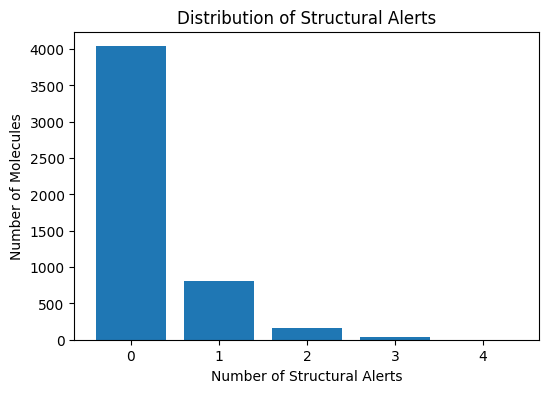

In [9]:
import matplotlib.pyplot as plt

counts = triazine_df["Alert_Count"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Number of Structural Alerts")
plt.ylabel("Number of Molecules")
plt.title("Distribution of Structural Alerts")
plt.show()

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw

hydrazine_df = triazine_df[
    triazine_df["BRENK_Alert"] == "hydrazine"
]

print(f"Hydrazine alerts: {len(hydrazine_df)}")

display(
    hydrazine_df[
        ["Triazine_ID", "SMILES"]
    ]
)

Hydrazine alerts: 18


,Triazine_ID,SMILES
337,TRZ00357,Cc1nnc(-c2ccnc(NN)c2)nc1C
410,TRZ00440,Cc1nnc(-c2cccc(NN)n2)nc1C
691,TRZ00767,CCn1cc(-c2nnc(C)c(C)n2)c(=O)c2cc(F)c(NN)cc21
906,TRZ01004,Cc1nnc(-c2ccc3[nH]c4c(c3c2)CCC/C4=N\N)nc1C
1084,TRZ01210,Cc1nnc(CC(NN)c2ccccc2O)nc1C
1177,TRZ01308,Cc1nnc(-c2nnc(NN)c3ccccc23)nc1C
1256,TRZ01398,COc1ccc(/C(=N/N)c2nnc(C)c(C)n2)cc1OC
1273,TRZ01415,Cc1nnc(-c2nc(NN)c(Cl)c(N)c2Cl)nc1C
1753,TRZ01959,C/C(=N\N)c1cc(-c2nnc(C)c(C)n2)c(=O)[nH]c1C
2001,TRZ02218,COc1c(NN)c(F)cc2c(=O)c(-c3nnc(C)c(C)n3)cn(C3CC...


In [20]:
acyl_df = triazine_df[
    triazine_df["BRENK_Alert"] == "acyl_hydrazine"
]

print(f"Acyl hydrazine alerts: {len(acyl_df)}")

display(
    acyl_df[
        ["Triazine_ID", "SMILES"]
    ]
)

Acyl hydrazine alerts: 2


,Triazine_ID,SMILES
2476,TRZ02717,Cc1nnc(-c2ccccc2C(=O)N(C)N)nc1C
2529,TRZ02770,Cc1nnc(C(=O)N(N)c2ccccc2)nc1C


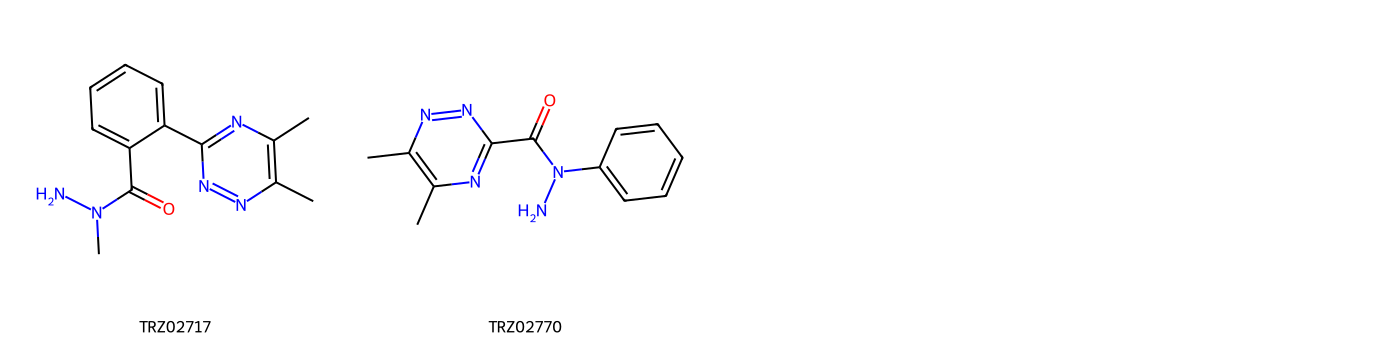

In [21]:
mols = [Chem.MolFromSmiles(s) for s in acyl_df["SMILES"]]

legends = [
    f"{tid}"
    for tid in acyl_df["Triazine_ID"]
]

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    legends=legends,
    subImgSize=(350,350)
)

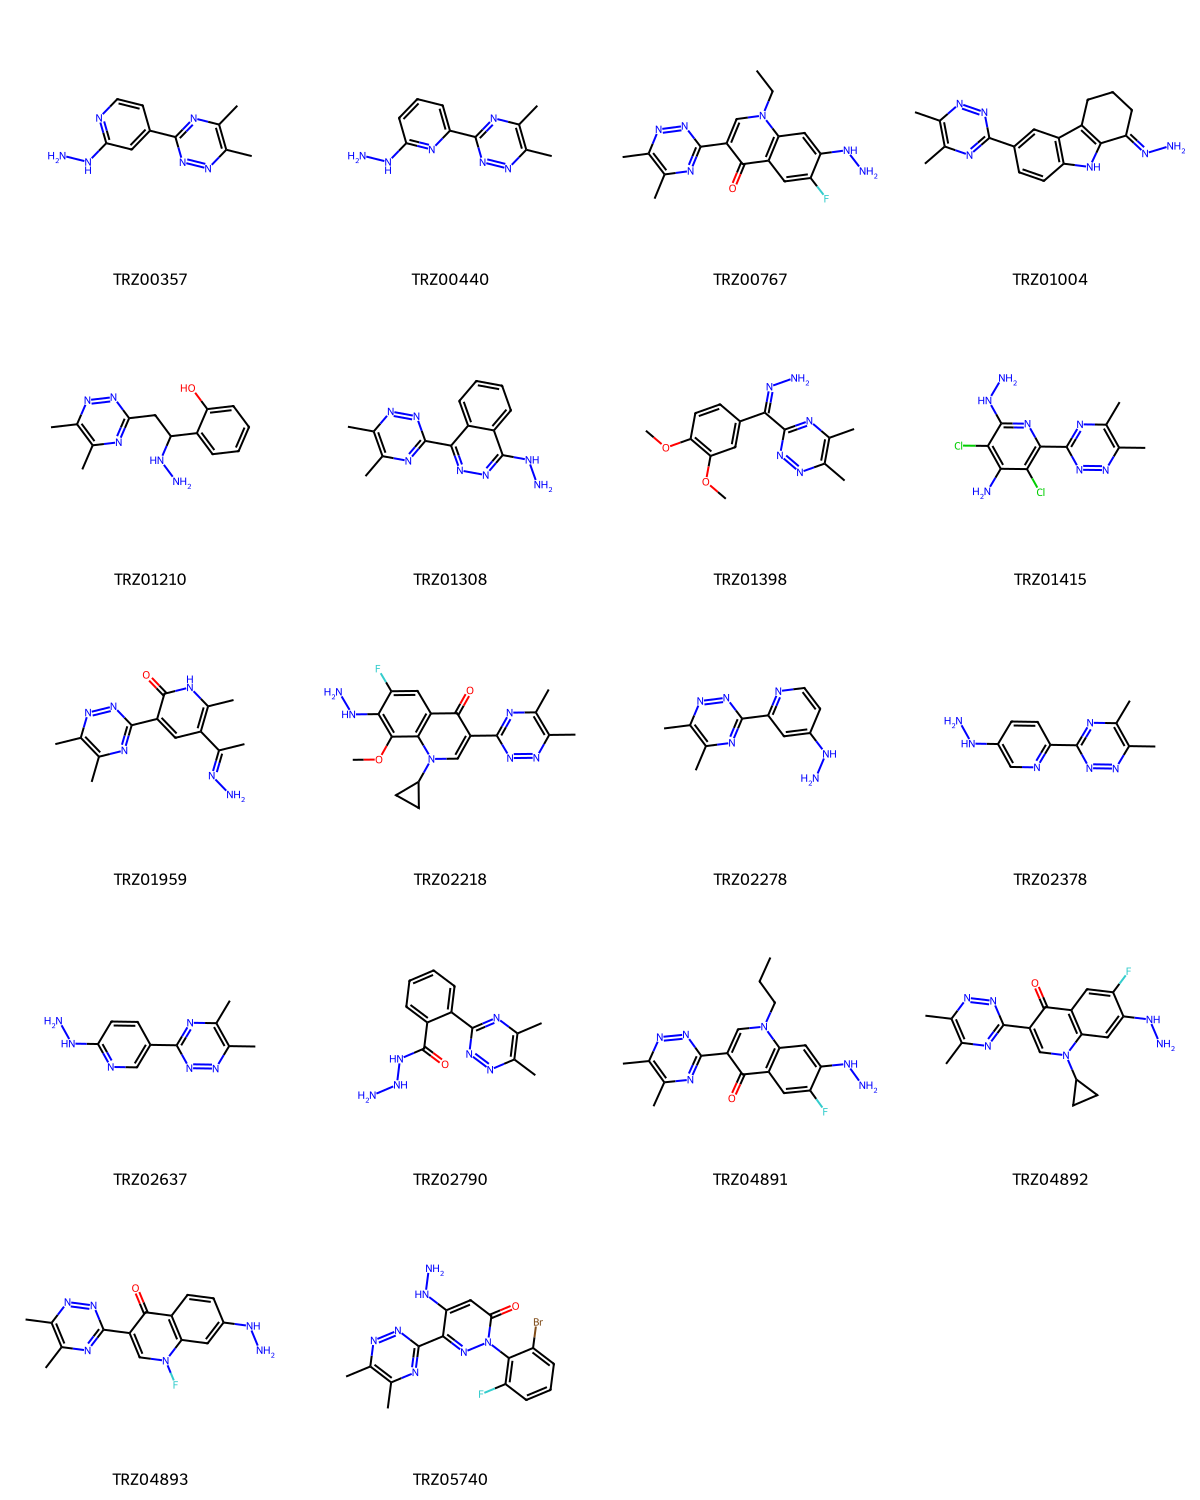

In [18]:
mols = [Chem.MolFromSmiles(s) for s in hydrazine_df["SMILES"]]

legends = [
    f"{tid}"
    for tid in hydrazine_df["Triazine_ID"]
]

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    legends=legends,
    subImgSize=(300,300)
)

In [ ]:
'''Molecules containing additional hydrazine or acyl hydrazide moieties outside the reacting hydrazide center were removed because these
functional groups are expected to undergo competing condensation with 2,3-butanedione, generating stable hydrazone intermediates that
cannot undergo the desired triazine cyclization under the optimized one-pot reaction conditions.'''


hydrazine = Chem.MolFromSmarts("[NX3][NX3]")
acyl_hydrazide = Chem.MolFromSmarts("[CX3](=O)[NX3][NX3]")

triazine_df["Has_Hydrazine"] = (
    triazine_df["mol"]
    .apply(lambda m: m.HasSubstructMatch(hydrazine))
)

triazine_df["Has_Acyl_Hydrazide"] = (
    triazine_df["mol"]
    .apply(lambda m: m.HasSubstructMatch(acyl_hydrazide))
)

triazine_df = triazine_df[
    ~(triazine_df["Has_Hydrazine"] |
      triazine_df["Has_Acyl_Hydrazide"])
].copy()

len(triazine_df)

4987

In [31]:
from rdkit.Chem import Descriptors

triazine_df["TPSA"] = (
    triazine_df["mol"]
    .apply(Descriptors.TPSA)
)

triazine_df["TPSA"].describe()

count    4987.000000
mean       69.583449
std        19.762329
min        38.670000
25%        54.105000
50%        67.770000
75%        82.510000
max       127.740000
Name: TPSA, dtype: float64

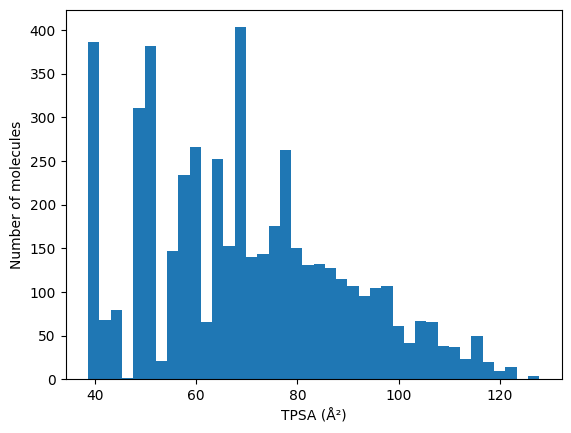

In [32]:
import matplotlib.pyplot as plt

plt.hist(triazine_df["TPSA"], bins=40)
plt.xlabel("TPSA (Å²)")
plt.ylabel("Number of molecules")
plt.show()